<a href="https://colab.research.google.com/github/DEIMRZZ/Activities./blob/main/Actividades/AF5_Procesamiento_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad Fundamental 5: Procesamiento de datos

**Docente:** Ing. Daniel Isaias López Páez  
**Hora de clase:** Jueves N1-N4  

**Integrantes:**
- Pedro Daniel Carbajal Cruz - 2222798
- Daniel Rodríguez Arellano - 2041848
- José Adrián Hernández Hernández - 1891823
- Edgar Ivan Martinez Ramirez - 2120721
- Luis Angel Rodriguez Gutierrez - 2059357

--- Primeras filas del dataset original ---
   Tiempo (s)  Distancia (cm)  Velocidad (cm/s)  Temperatura (°C)
0           0       43.708611          9.256646         23.925585
1           1       95.564288         27.095047         23.704682
2           2       75.879455         43.647292         33.593819
3           3       63.879264         36.611244         23.743193
4           4       24.041678         40.328057         24.079246
--- Resumen de limpieza ---
Filas originales: 1000
Filas tras eliminar nulos y atípicos: 913

--- Primeras filas del dataset limpio ---
   Tiempo (s)  Distancia (cm)  Velocidad (cm/s)  Temperatura (°C)
0           0       43.708611          9.256646         23.925585
1           1       95.564288         27.095047         23.704682
2           2       75.879455         43.647292         33.593819
3           3       63.879264         36.611244         23.743193
4           4       24.041678         40.328057         24.079246
--- Primeras filas del datas

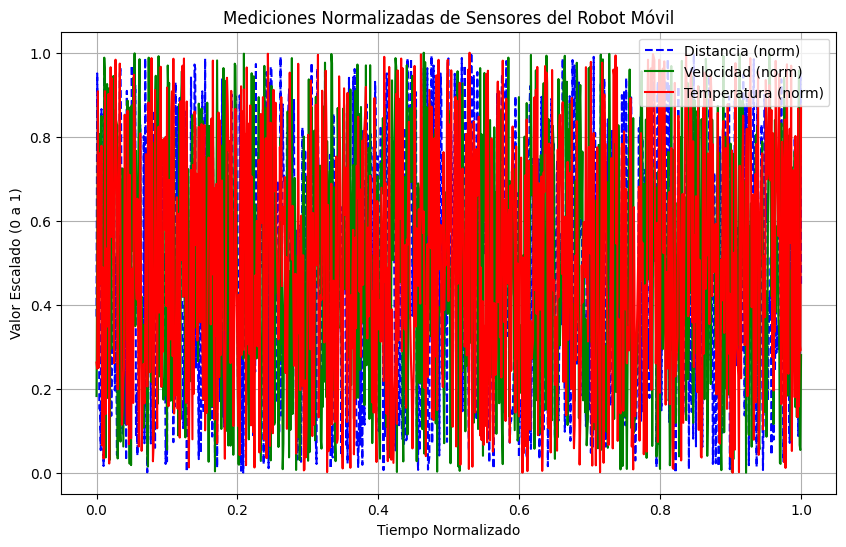

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar el dataset directamente desde GitHub
url = "https://raw.githubusercontent.com/dilp90/InteligenciaArtificial_y_RedesNeuronales_UANL_FIME/main/MachineLearning/Datasets/robot_sensors.csv"
df = pd.read_csv(url)

# Mostrar las primeras filas para verificar los datos
print("--- Primeras filas del dataset original ---")
print(df.head())

# 1. Eliminamos valores nulos (NaN)
# 2. Filtramos la velocidad para eliminar registros atípicos (valores negativos)

df_limpio = df.dropna().copy()
df_limpio = df_limpio[df_limpio['Velocidad (cm/s)'] >= 0]

print("--- Resumen de limpieza ---")
print(f"Filas originales: {len(df)}")
print(f"Filas tras eliminar nulos y atípicos: {len(df_limpio)}")
print("\n--- Primeras filas del dataset limpio ---")
print(df_limpio.head())

# Aplicar la fórmula de Min-Max Scaling a cada columna numérica
cols = ['Tiempo (s)', 'Distancia (cm)', 'Velocidad (cm/s)', 'Temperatura (°C)']

df_norm = df_limpio.copy()
for col in cols:
    min_val = df_limpio[col].min()
    max_val = df_limpio[col].max()
    df_norm[col] = (df_limpio[col] - min_val) / (max_val - min_val)

print("--- Primeras filas del dataset normalizado ---")
print(df_norm.head())

# Graficar las variables normalizadas
plt.figure(figsize=(10, 6))

plt.plot(df_norm['Tiempo (s)'], df_norm['Distancia (cm)'], label='Distancia (norm)', color='blue', linestyle='--')
plt.plot(df_norm['Tiempo (s)'], df_norm['Velocidad (cm/s)'], label='Velocidad (norm)', color='green')
plt.plot(df_norm['Tiempo (s)'], df_norm['Temperatura (°C)'], label='Temperatura (norm)', color='red')

plt.title('Mediciones Normalizadas de Sensores del Robot Móvil')
plt.xlabel('Tiempo Normalizado')
plt.ylabel('Valor Escalado (0 a 1)')
plt.legend()
plt.grid(True)
plt.show()



## Ejercicio 2: Preguntas y Análisis

1. **¿Cómo afecta la limpieza de datos al análisis del dataset?**
   - La limpieza elimina inconsistencias como valores nulos o lecturas atípicas (como velocidades negativas). Esto evita errores en cálculos estadísticos y previene que los modelos de Machine Learning aprendan patrones ruidosos o irreales.

2. **¿Por qué es importante la normalización en Machine Learning?**
   - Cada sensor mide en escalas distintas (distancia en cientos de cm, temperatura en decenas de °C). La normalización escala todos los atributos al rango [0, 1], asegurando que ninguna variable domine a las demás en el modelo debido a su magnitud.

3. **¿Cómo interpretarías los datos visualizados?**
   - Al estar todos los datos en la misma escala (0 a 1), podemos analizar la relación temporal entre las variables, como el comportamiento de la velocidad según la proximidad de un obstáculo y la estabilidad de la temperatura durante el recorrido.
   

---
### Referencias

- Matthes, E. (2023). *Python crash course*. No Starch Press.
- W3Schools. (s. f.). *Python Tutorial*. Recuperado de [https://www.w3schools.com/python/default.asp](https://www.w3schools.com/python/default.asp)